In [ ]:
# 绘制省市县地图及其各种投影方式

import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.lines import Line2D
from shapely.geometry import Polygon

plt.rcParams['font.sans-serif'] = ['SimHei','Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

def loopFillColor(ax, world, countryList, color, alpha):
    for country in countryList:
        country_data = world[world['NAME_CHN'] == country]
        if not country_data.empty:
            country_data.plot(ax=ax, color=color, edgecolor='#CCCCCC', linewidth=0.4, transform=ccrs.PlateCarree(), alpha=alpha)


world = gpd.read_file('./shp2json/chinaprovince.geojson')
world = world.to_crs(epsg=4326)
line = world[world.geom_type.isin(['LineString', 'MultiLineString'])]

city = gpd.read_file('./shp2json/chinacity.geojson')
city = city.to_crs(epsg=4326)

county = gpd.read_file('./shp2json/chinacounty.geojson')
county = county.to_crs(epsg=4326)



fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=105)})
county.plot(ax=ax, color='none', edgecolor='dimgray', linewidth=0.1, transform=ccrs.PlateCarree())
city.plot(ax=ax, color='none', edgecolor='k', linewidth=0.2, transform=ccrs.PlateCarree())
world.plot(ax=ax, color='none', edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree())
line.plot(ax=ax, color='dimgray', edgecolor='dimgray', linewidth=0.3, transform=ccrs.PlateCarree())


ax.tick_params(axis='both', which='both', length=0, labelsize=0)
ax.set_extent([71.5, 136.4, 17.5, 54.5], crs=ccrs.PlateCarree())
plt.savefig('output3.png', dpi=1200, bbox_inches='tight')
plt.show()

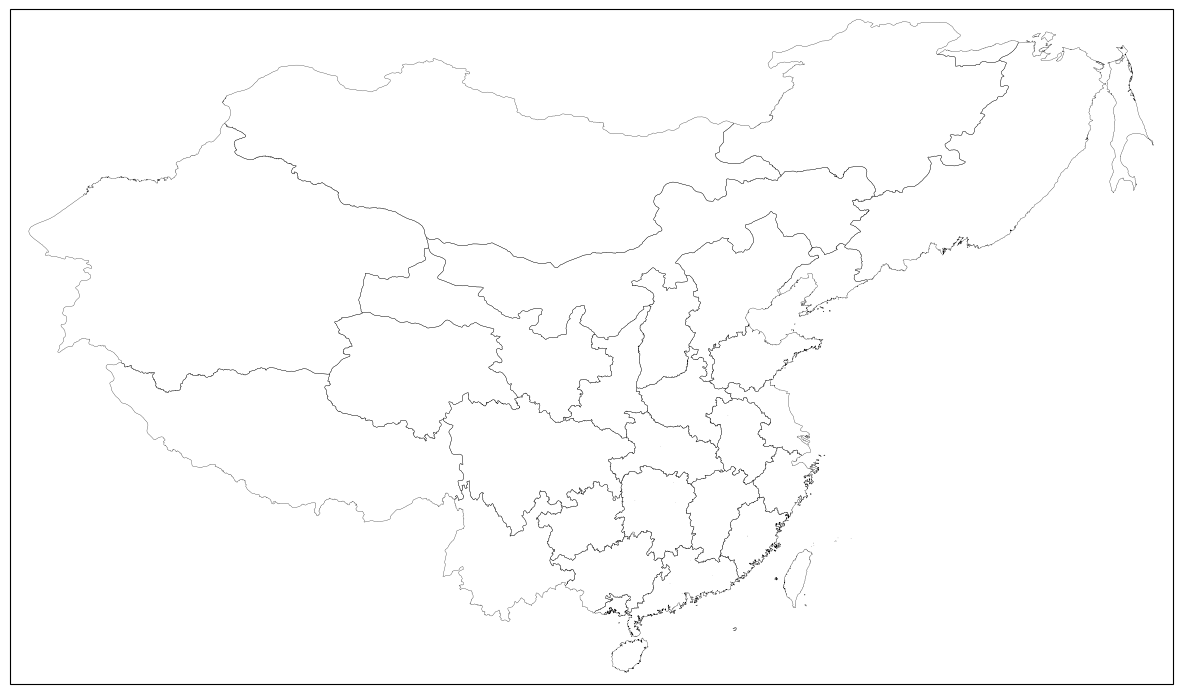

In [7]:
# 绘制清朝/民国地图

import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.lines import Line2D
from shapely.geometry import Polygon

plt.rcParams['font.sans-serif'] = ['SimHei','Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

def loopFillColor(ax, world, countryList, color, alpha):
    for country in countryList:
        country_data = world[world['NAME_CHN'] == country]
        if not country_data.empty:
            country_data.plot(ax=ax, color=color, edgecolor='#CCCCCC', linewidth=0.4, transform=ccrs.PlateCarree(), alpha=alpha)


# world = gpd.read_file('./cultural/1926_orig/1926/1926.shp')
# world = world.to_crs(epsg=4326)

# border1 = gpd.read_file('./cultural/1926_orig/未定国界1.geojson')
# border1 = border1.to_crs(epsg=4326)
# border2 = gpd.read_file('./cultural/1926_orig/未定国界2.geojson')
# border2 = border2.to_crs(epsg=4326)
# border3 = gpd.read_file('./cultural/1926_orig/未定国界3.geojson')
# border3 = border3.to_crs(epsg=4326)
# nanhai = gpd.read_file('./cultural/1926_orig/南海补丁/南海诸岛.shp')
# nanhai = nanhai.to_crs(epsg=4326)
world = gpd.read_file('./cultural/v6_1820_prov_pgn_utf/v6_1820_prov_pgn_utf.shp')
world = world.to_crs(epsg=4326)


fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=105)})
# county.plot(ax=ax, color='none', edgecolor='dimgray', linewidth=0.1, transform=ccrs.PlateCarree())
# city.plot(ax=ax, color='none', edgecolor='k', linewidth=0.2, transform=ccrs.PlateCarree())
world.plot(ax=ax, color='none', edgecolor='k', linewidth=0.2, transform=ccrs.PlateCarree())
# border1.plot(ax=ax, color='lightgray', edgecolor='lightgray', linewidth=0.2, transform=ccrs.PlateCarree())
# border2.plot(ax=ax, color='lightgray', edgecolor='lightgray', linewidth=0.2, transform=ccrs.PlateCarree())
# border3.plot(ax=ax, color='lightgray', edgecolor='lightgray', linewidth=0.2, transform=ccrs.PlateCarree())
# nanhai.plot(ax=ax, color='k', edgecolor='k', linewidth=0.2, transform=ccrs.PlateCarree())
# line.plot(ax=ax, color='dimgray', edgecolor='dimgray', linewidth=0.3, transform=ccrs.PlateCarree())


ax.tick_params(axis='both', which='both', length=0, labelsize=0)
ax.set_extent([68.5, 146, 17.5, 56.5], crs=ccrs.PlateCarree())
plt.savefig('output4.png', dpi=1200, bbox_inches='tight')
# ax.set_axis_off()
# plt.savefig('roc1926.png', dpi=1200, bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

In [ ]:
# 标准中国地图
# PNG 透明背景

import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import LineString
import shapely
import pandas as pd
import numpy as np
from pyproj import Geod

china_city = gpd.read_file('./shp2json/chinacity.geojson')
china_city = china_city.to_crs(ccrs.PlateCarree())
china_province = gpd.read_file('./shp2json/chinaprovince.geojson')
china_province = china_province.to_crs(ccrs.PlateCarree())
china_county = gpd.read_file('./shp2json/chinacounty.geojson')
china_county = china_county.to_crs(ccrs.PlateCarree())
tenline = gpd.read_file('./shp2json/tenline.geojson')
tenline = tenline.to_crs(ccrs.PlateCarree())
undefined_border = gpd.read_file('./shp2json/undefined_border.geojson')
undefined_border = undefined_border.to_crs(ccrs.PlateCarree())

# tw = gpd.read_file('./台湾.geojson')
# tw = tw.to_crs(ccrs.PlateCarree())


fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={'projection': ccrs.LambertConformal(central_longitude=105, central_latitude=35, standard_parallels=(25, 47))})
# fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={'projection': ccrs.Miller(central_longitude=105)})

# china_county.plot(ax=ax, color='w', edgecolor='dimgray', linewidth=0.1, transform=ccrs.PlateCarree())
# china_city.plot(ax=ax, color='none', edgecolor='dimgray', linewidth=0.2, transform=ccrs.PlateCarree())
china_province.plot(ax=ax, color='none', edgecolor='dimgray', linewidth=0.4, transform=ccrs.PlateCarree())
# railway.plot(ax=ax, color='#079342', edgecolor="#079342", linewidth=0.3, transform=ccrs.PlateCarree())

# tw.plot(ax=ax, color='none', edgecolor='dimgray', linewidth=0.1, transform=ccrs.PlateCarree())

tenline.plot(ax=ax, color='dimgray', edgecolor='dimgray', linewidth=0.4, transform=ccrs.PlateCarree())
undefined_border.plot(ax=ax, color='#C1C1C1', edgecolor='#C1C1C1', linewidth=0.2, transform=ccrs.PlateCarree())



plt.savefig('map16.png', dpi=2400, bbox_inches='tight')
# ax.set_axis_off()
# plt.savefig('china_map1.png', dpi=1200, bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()


In [ ]:
# 绘制美国地图

import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False 


def loopFillColor(ax, world, countryList, color, alpha):
    for country in countryList:
        country_data = world[world['FCNAME'] == country]
        if not country_data.empty:
            country_data.plot(ax=ax, color=color, edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree(), alpha=alpha)


# 读取地图数据
world = gpd.read_file('./cultural/American_civil_war.json')
world = world.to_crs(ccrs.PlateCarree())


# 创建绘图对象
fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={'projection': ccrs.Miller(central_longitude=-100)})
world.plot(ax=ax, color='w', edgecolor='k', linewidth=0.3, transform=ccrs.PlateCarree())

# 本地数据集下的北美周范围如下：
# countries_to_fill4 = ['加拿大', '美国', '墨西哥', '格陵兰', '危地马拉', '伯利兹', '萨尔瓦多', '洪都拉斯', '尼加拉瓜', '哥斯达黎加', '巴拿马',
#                       '巴哈马', '古巴', '海地', '多米尼加', '牙买加', '波多黎各', '特克斯和凯科斯群岛', '开曼群岛', '英属维尔京群岛', '美属维尔京群岛', 
#                       '安圭拉', '瓜德罗普', '圣基茨和尼维斯', '安提瓜和巴布达', '蒙特塞拉特', '多米尼克', '马提尼克', '圣卢西亚', '圣文森特和格林纳丁斯', 
#                       '巴巴多斯', '格林纳达', '特立尼达和多巴哥', '阿鲁巴', '荷属安的列斯', '圣皮埃尔和密克隆', '百慕大']
# loopFillColor(ax, world, countries_to_fill4, "w", 1)

# 保存图像并显示
plt.savefig('uscivilwar.png', dpi=1200, bbox_inches='tight')
plt.show()


In [ ]:
# 标准世界地图-画法1
# 使用worldmap1文件，shp格式，数据量较大，边界较详细

import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False 


def loopFillColor(ax, world, countryList, color, alpha):
    for country in countryList:
        country_data = world[world['FCNAME'] == country]
        if not country_data.empty:
            country_data.plot(ax=ax, color=color, edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree(), alpha=alpha)


# 读取地图数据
world = gpd.read_file('./worldmap1/World_countries.shp')
world = world.to_crs(ccrs.PlateCarree())

tenline = gpd.read_file('./line/worldmap1/十段线.geojson')
tenline = tenline.to_crs(ccrs.PlateCarree())

border = gpd.read_file('./line/worldmap1/未定国界.geojson')
border = border.to_crs(ccrs.PlateCarree())

Palestine = gpd.read_file('./line/worldmap1/巴勒斯坦.geojson')
Palestine = Palestine.to_crs(ccrs.PlateCarree())

Kashmir = gpd.read_file('./line/worldmap1/克什米尔.geojson')
Kashmir = Kashmir.to_crs(ccrs.PlateCarree())

PIline1 = gpd.read_file('./line/worldmap1/印巴停火线part1.geojson')
PIline1 = PIline1.to_crs(ccrs.PlateCarree())

PIline2 = gpd.read_file('./line/worldmap1/印巴停火线part2.geojson')
PIline2 = PIline2.to_crs(ccrs.PlateCarree())


# 创建绘图对象
fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={'projection': ccrs.Miller(central_longitude=150)})
world.plot(ax=ax, color='w', edgecolor='k', linewidth=0.3, transform=ccrs.PlateCarree())

tenline.plot(ax=ax, color='k', edgecolor='k', linewidth=0.3, linestyle='-', transform=ccrs.PlateCarree())
border.plot(ax=ax, color='w', edgecolor='w', linewidth=0.2, linestyle='-', transform=ccrs.PlateCarree())

Palestine.plot(ax=ax, color='w', edgecolor='k', linewidth=0.3, linestyle='-', transform=ccrs.PlateCarree())

Kashmir.plot(ax=ax, color='k', edgecolor='k', linewidth=0.3, linestyle='--', transform=ccrs.PlateCarree())
PIline1.plot(ax=ax, color='w', edgecolor='w', linewidth=0.4, linestyle='--', transform=ccrs.PlateCarree())
PIline2.plot(ax=ax, color='w', edgecolor='w', linewidth=0.4, linestyle='--', transform=ccrs.PlateCarree())

# 本地数据集下的北每周范围如下：
# countries_to_fill4 = ['加拿大', '美国', '墨西哥', '格陵兰', '危地马拉', '伯利兹', '萨尔瓦多', '洪都拉斯', '尼加拉瓜', '哥斯达黎加', '巴拿马',
#                       '巴哈马', '古巴', '海地', '多米尼加', '牙买加', '波多黎各', '特克斯和凯科斯群岛', '开曼群岛', '英属维尔京群岛', '美属维尔京群岛', 
#                       '安圭拉', '瓜德罗普', '圣基茨和尼维斯', '安提瓜和巴布达', '蒙特塞拉特', '多米尼克', '马提尼克', '圣卢西亚', '圣文森特和格林纳丁斯', 
#                       '巴巴多斯', '格林纳达', '特立尼达和多巴哥', '阿鲁巴', '荷属安的列斯', '圣皮埃尔和密克隆', '百慕大']
# loopFillColor(ax, world, countries_to_fill4, "w", 1)
  
# 保存图像并显示
plt.savefig('worldmap1.png', dpi=1200, bbox_inches='tight')
plt.show()


In [ ]:
# 亚洲地图

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.patheffects as PathEffects


world = gpd.read_file('./worldmap4/world_uk.geojson')
world = world.to_crs(ccrs.PlateCarree())
tenline = gpd.read_file('./shp2json/tenline.geojson')
tenline = tenline.to_crs(ccrs.PlateCarree())
fifa_plugin = gpd.read_file('./kml2geojson/fifa_plugin.geojson')
fifa_plugin = fifa_plugin.to_crs(ccrs.PlateCarree())
continental_plugin = gpd.read_file('./kml2geojson/continent_line.geojson')
continental_plugin = continental_plugin.to_crs(ccrs.PlateCarree())

fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={'projection': ccrs.Miller(central_longitude=150)})
# ax.set_facecolor('w')
world.plot(ax=ax, color='none', edgecolor='none', linewidth=0.4, transform=ccrs.PlateCarree())
# tenline.plot(ax=ax, color='#CCCCCC', edgecolor='#CCCCCC', linewidth=0.4, transform=ccrs.PlateCarree())
# fifa_plugin.plot(ax=ax, color='#CCCCCC', edgecolor="#CCCCCC", linewidth=0.4, linestyle='--', transform=ccrs.PlateCarree())
continental_plugin.plot(ax=ax, color='r', edgecolor="r", linewidth=1.2, linestyle='--', transform=ccrs.PlateCarree())

# 西岸+加沙
palestine = gpd.read_file('./kml2geojson/Palestine.geojson')
palestine = palestine.to_crs(ccrs.PlateCarree())
# palestine.plot(ax=ax, color='w', edgecolor='#CCCCCC', linewidth=0.4, transform=ccrs.PlateCarree())

# 克什米尔
plugin = gpd.read_file('./kml2geojson/克什米尔.geojson')
plugin = plugin.to_crs(ccrs.PlateCarree())
# plugin.plot(ax=ax, color='#CCCCCC', edgecolor='#CCCCCC', linewidth=0.4, linestyle='--', transform=ccrs.PlateCarree())

# 截图
ax.tick_params(axis='both', which='both', length=0, labelsize=0)
# 亚洲范围
# ax.set_extent([32, 151, -12, 58], crs=ccrs.PlateCarree())
# 保存和显示图片
plt.savefig('output2.png', dpi=1200, bbox_inches='tight')
plt.show()


In [ ]:
# 非洲地图

import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D


# 民国1926地图
EU_province = gpd.read_file('./cultural/AFRICA/africamap/World_countries.shp')
EU_province = EU_province.to_crs(ccrs.PlateCarree())
# EU_country = gpd.read_file('./cultural/EU/World_countries.shp')
# EU_country = EU_country.to_crs(ccrs.PlateCarree())

fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={'projection': ccrs.Miller(central_longitude=20)})
EU_province.plot(ax=ax, color="w", edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree())
# EU_country.plot(ax=ax, color="none", edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree())

plt.savefig('AF.png', dpi=1600, bbox_inches='tight')
# ax.set_axis_off()
# plt.savefig('EU_province2.png', dpi=1200, bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()


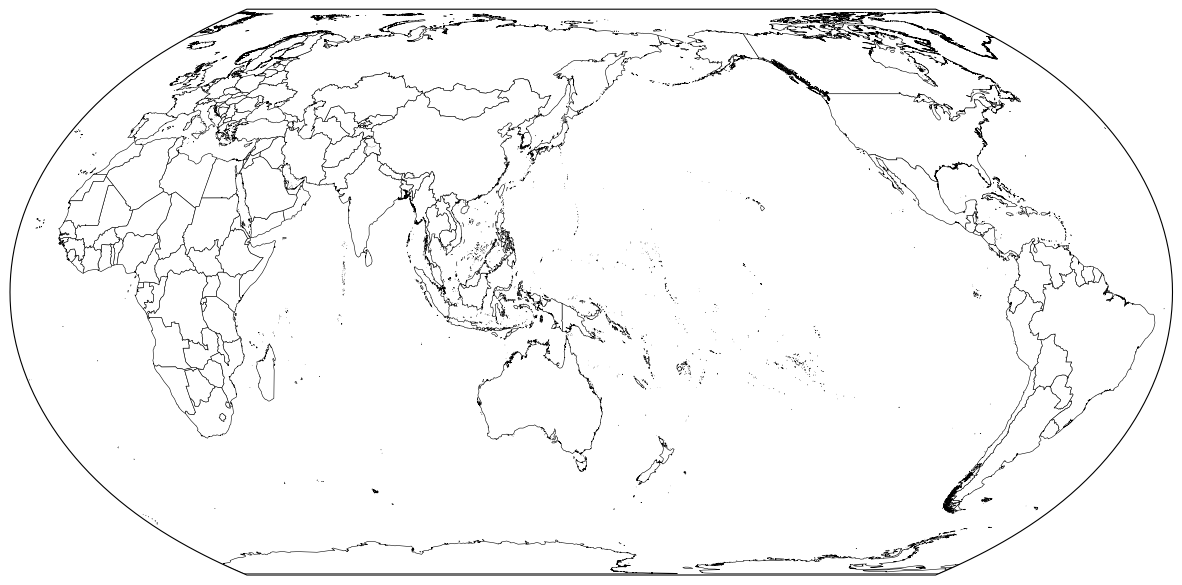

In [10]:
# EqualEarth（平等地球）标准世界地图

import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.lines import Line2D

plt.rcParams['font.sans-serif'] = ['SimHei','Times New Roman']
plt.rcParams['axes.unicode_minus'] = False


def loopFillColor(ax, world, countryList, color, alpha):
    for country in countryList:
        country_data = world[world['NAME_CHN'] == country]
        if not country_data.empty:
            country_data.plot(ax=ax, color=color, edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree(), alpha=alpha)


world = gpd.read_file('./worldmap4/world.geojson')
world = world.to_crs(ccrs.PlateCarree())

tenline = gpd.read_file('./line/worldmap2/十段线.geojson')
tenline = tenline.to_crs(ccrs.PlateCarree())

border = gpd.read_file('./line/worldmap2/未定国界.geojson')
border = border.to_crs(ccrs.PlateCarree())

PIline = gpd.read_file('./line/worldmap2/印巴停火线part1.geojson')
PIline = PIline.to_crs(ccrs.PlateCarree())

Palestine = gpd.read_file('./line/worldmap2/巴勒斯坦.geojson')
Palestine = Palestine.to_crs(ccrs.PlateCarree())

fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={'projection': ccrs.EqualEarth(central_longitude=150)})
world.plot(ax=ax, color="w", edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree())

Palestine.plot(ax=ax, color='w', edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree())   
tenline.plot(ax=ax, color='k', edgecolor='k', linewidth=0.4, linestyle='-', transform=ccrs.PlateCarree())
border.plot(ax=ax, color='#CCCCCC', edgecolor='#CCCCCC', linewidth=0.2, linestyle='-', transform=ccrs.PlateCarree())
PIline.plot(ax=ax, color='k', edgecolor='k', linewidth=0.2, linestyle='--', transform=ccrs.PlateCarree())

ax.set_aspect('equal')
plt.savefig('EqualEarthWorldMap.png', dpi=1200, bbox_inches='tight')
plt.show()


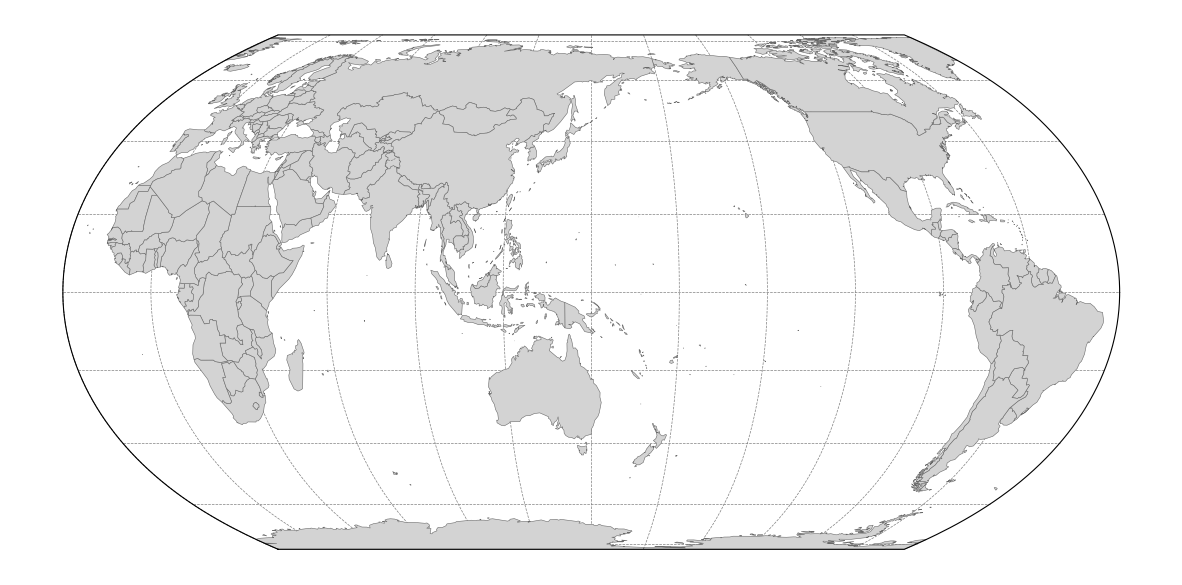

In [29]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer
import shapely

# 1. 完美的 PROJ 字符串定义
# +lat_1=50.467 : 标准纬线，控制地图整体不会过宽
# +R=6371000    : 强制使用半径为 6371km 的标准球体，防止椭球体造成畸变
proj_str = "+proj=eqearth +lon_0=150"
# proj_str = "+proj=merc +lon_0=150"

transformer = Transformer.from_crs("EPSG:4326", proj_str, always_xy=True)
bbox = shapely.box(-180, -85, 180, 85)

world = gpd.read_file('./worldmap4/world8859.geojson')
# world['geometry'] = world['geometry'].buffer(0)
# world = world.clip(bbox)
world_wintri = world.to_crs(proj_str)
border = gpd.read_file('./line/worldmap8859/未定国界.geojson')
border = border.to_crs(proj_str)
Kashmir = gpd.read_file('./line/worldmap8859/克什米尔_面.geojson')
Kashmir = Kashmir.to_crs(proj_str)
PILine1 = gpd.read_file('./line/worldmap8859/印巴停火线part1.geojson')
PILine1 = PILine1.to_crs(proj_str)


fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# ---------------- 关键修复点 ----------------
# 强制保持 X轴 和 Y轴 坐标的物理比例为 1:1，绝对禁止拉伸！
ax.set_aspect('equal')
# --------------------------------------------

# 绘制陆地多边形
world_wintri.plot(ax=ax, color="lightgray", edgecolor='dimgray', linewidth=0.4, zorder=2)
border.plot(ax=ax, color='#C1C1C1', edgecolor='#C1C1C1', linewidth=0.2, zorder=2)
Kashmir.plot(ax=ax, color='lightgray', edgecolor='dimgray', linewidth=0.4, linestyle='-', zorder=2)
PILine1.plot(ax=ax, color='dimgray', edgecolor='dimgray', linewidth=0.4, linestyle='--', zorder=2)

# 计算经度范围
lon_min, lon_max = 150 - 179.999, 150 + 179.999

# 绘制纬线 (每 20 度)
for lat in range(-80, 81, 20):
    lons = np.linspace(lon_min, lon_max, 100)
    lats = np.full_like(lons, lat)
    x, y = transformer.transform(lons, lats)  
    ax.plot(x, y, color='gray', linestyle='--', linewidth=0.5, zorder=1)

# 绘制经线 (每 30 度)
for lon in range(-30, 331, 30):
    lats = np.linspace(-89.999, 89.999, 100)
    lons = np.full_like(lats, lon)
    x, y = transformer.transform(lons, lats)
    ax.plot(x, y, color='gray', linestyle='--', linewidth=0.5, zorder=1)

# 绘制地球最外围轮廓框
boundary_lons = np.concatenate([
    np.linspace(lon_min, lon_max, 100),
    np.full(100, lon_max),
    np.linspace(lon_max, lon_min, 100),
    np.full(100, lon_min)
])
boundary_lats = np.concatenate([
    np.full(100, -89.999),
    np.linspace(-89.999, 89.999, 100),
    np.full(100, 89.999),
    np.linspace(89.999, -89.999, 100)
])

bx, by = transformer.transform(boundary_lons, boundary_lats)
ax.plot(bx, by, color='black', linewidth=0.8, zorder=3)

ax.set_axis_off() 
# plt.savefig('MercatorWorldMap.png', dpi=1200, bbox_inches='tight')
plt.show()